# Performing Random Forest

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
file_path = '/home/avantikapatil/vscode/Bp project/final_32_columns_no_outliers.parquet'
print("Loading data...")
df = pd.read_parquet(file_path)

# ---------------------------------------------------------
# 2. Define Features (X) and Target (y)
# ---------------------------------------------------------
# Your target variable is totalFare
X = df.drop('totalFare', axis=1)
y = df['totalFare']

# Standard 80/20 Train-Test Split to ensure we have unseen testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Prevent OOM Errors: Sample the Training Data
# ---------------------------------------------------------
# We take a 20% representative sample of the TRAINING data for tuning
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. Setup Random Forest & Hyperparameter Grid
# ---------------------------------------------------------
rf = RandomForestRegressor(random_state=42)

# Define the grid of parameters to search through
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees in the forest
    'max_depth': [None, 15, 25, 35],        # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],        # Min samples required to split a node
    'min_samples_leaf': [1, 2, 4],          # Min samples required to be at a leaf
    'max_features': ['sqrt', 'log2', 1.0]   # Number of features considered at splits
}

# ---------------------------------------------------------
# 5. Perform RandomizedSearchCV on the 20% Sample
# ---------------------------------------------------------
# n_jobs=-1 uses all available CPU cores to speed up the process
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, 
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

print("Tuning hyperparameters on the 20% training sample...")
rf_random.fit(X_tune, y_tune)

print("\nBest Parameters Found:")
print(rf_random.best_params_)

# ---------------------------------------------------------
# 6. Train Final Model on 100% of the Training Data
# ---------------------------------------------------------
best_rf = rf_random.best_estimator_

print("\nTraining the final model on 100% of the training dataset. This may take a while...")
best_rf.fit(X_train, y_train)

# ---------------------------------------------------------
# 7. Evaluate on Unseen Test Data
# ---------------------------------------------------------
print("\nEvaluating the model on the test data...")
y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n--- Final Random Forest Performance ---")
print(f"Test R-squared: {r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAPE: {mape:.4%}")

Loading data...
Tuning hyperparameters on the 20% training sample...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  30.2s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  31.9s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  38.6s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  39.5s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  41.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  41.2s
[CV] END max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  49.0s
[CV] END max_depth=15, max_

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error



print(f"Testing RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Testing MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Predictions strictly within $25: {np.mean(np.abs(y_test - y_pred) <= 25) * 100:.2f}%")

Testing RMSE: 82.94
Testing MAE:  57.53
Predictions strictly within $25: 35.82%



Generating Feature Importance Graph...


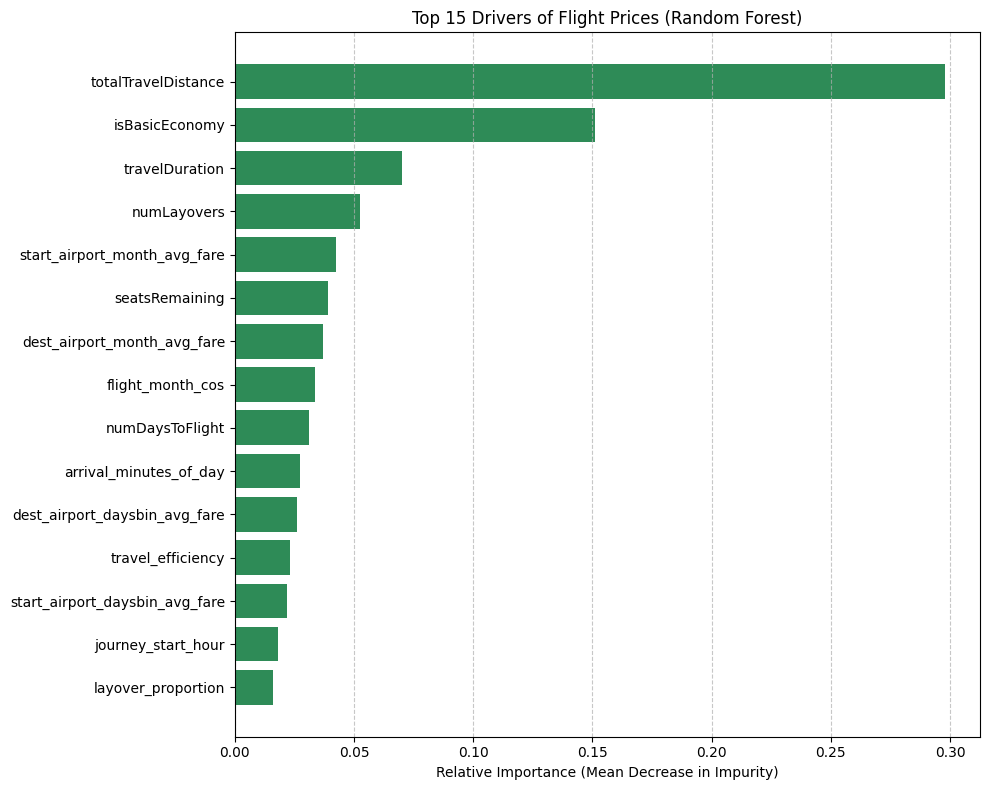

In [6]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 8. Feature Importance Visualization
# ---------------------------------------------------------
print("\nGenerating Feature Importance Graph...")

# Extract the feature importances from the best Random Forest model
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame to hold the features and their importance scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Select the Top 15 most important features
top_15 = importance_df.tail(15)

# Plotting
plt.figure(figsize=(10, 8))
plt.barh(top_15['Feature'], top_15['Importance'], color='seagreen')
plt.xlabel('Relative Importance (Mean Decrease in Impurity)')
plt.title('Top 15 Drivers of Flight Prices (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure if you want to include it in your LaTeX report!
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()